# K-Means Clustering (Combined Dataset) - Pipeline

Train a K-Means clustering model for email spam detection using a scikit-learn Pipeline.

## Notebook Structure
1. Import modules
2. Load dataset
3. Split data
4. Create and train pipeline
5. Map clusters to labels
6. Evaluate model
7. Visualize results
8. Save model (.pkl)

In [1]:
# scikit-learn components: TF-IDF, KMeans, Pipeline, PCA, metrics
# Standard library, data processing, and visualization imports
import sys
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR,
    MODEL_OUTPUT_DIR, RESULTS_DIR
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn import metrics


In [2]:
# Load the preprocessed combined dataset (Enron + TREC06P)
df = pd.read_csv(PROCESSED_DATA_DIR / "cleaned_combined.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(2)


Shape: (121084, 11)
Columns: ['label', 'text', 'num_urls', 'num_exclamation', 'num_question', 'num_dollar', 'num_all_caps', 'num_numbers', 'word_count', 'capital_ratio', 'emoji_count']


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
0,0,receiv nahou-msmbx01v [phonenumber] nahou-msmb...,41,0,0,3,240,407,2319,0.145347,0
1,0,receiv nahou-msmbx03vcorpenroncom [phonenumber...,0,1,0,0,19,56,166,0.230851,0


In [3]:
# Check class balance between ham (0) and spam (1)
df["label"].value_counts()


label
1    61083
0    60001
Name: count, dtype: int64

In [4]:
# Use only the text column as feature for clustering (unsupervised)
TEXT_COL = "text"
TARGET = "label"

X = df[TEXT_COL]
y = df[TARGET]

print(f"Text samples: {len(X)}")
print(f"Target distribution:\n{y.value_counts()}")


Text samples: 121084
Target distribution:
label
1    61083
0    60001
Name: count, dtype: int64


In [5]:
# Stratified split preserves class proportions in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(y_train)}  Test: {len(y_test)}")
print(f"Train pos: {y_train.sum()}  Test pos: {y_test.sum()}")


Train: 96867  Test: 24217
Train pos: 48866  Test pos: 12217


In [6]:
# KMeans is fit unsupervised; cluster-to-label mapping is done in the next cell
# TF-IDF params: max_features=50000, sublinear_tf, ngram_range=(1,2), max_df=0.7, min_df=5
# Pipeline chains TF-IDF vectorization with KMeans clustering
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000, sublinear_tf=True, ngram_range=(1, 2),
        max_df=0.7, min_df=5, stop_words="english",
    )),
    ("kmeans", KMeans(n_clusters=2, random_state=42, n_init=10)),
])

pipeline.fit(X_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [7]:
# map_0 and map_1 store the predicted class label for each cluster (0 or 1)
# Assign cluster labels by majority vote using training data ground truth
train_clusters = pipeline.predict(X_train)

c0_labels = y_train[train_clusters == 0]
c1_labels = y_train[train_clusters == 1]

map_0 = int(c0_labels.mode()[0] if len(c0_labels) > 0 else 0)
map_1 = int(c1_labels.mode()[0] if len(c1_labels) > 0 else 1)

train_preds = np.where(train_clusters == 0, map_0, map_1)
test_clusters = pipeline.predict(X_test)
test_preds = np.where(test_clusters == 0, map_0, map_1)

train_acc = metrics.accuracy_score(y_train, train_preds)
test_acc = metrics.accuracy_score(y_test, test_preds)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Cluster 0 -> label {map_0}, Cluster 1 -> label {map_1}")


Train accuracy: 0.6924
Test accuracy:  0.6931
Cluster 0 -> label 0, Cluster 1 -> label 1


In [8]:
# Compute predicted labels (via cluster mapping) and probability scores on the test set
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def _sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -100, 100)))

tfidf_test = pipeline.named_steps["tfidf"].transform(X_test)
dists = pipeline.named_steps["kmeans"].transform(tfidf_test)
spam_centroid = 0 if map_0 == 1 else 1
y_prob = _sigmoid(-dists[:, spam_centroid])

y_pred = test_preds

print("=== K-Means Clustering Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))


=== K-Means Clustering Results ===
Accuracy:  0.6931
Precision: 0.8050
Recall:    0.5168
F1 Score:  0.6295
ROC-AUC:   0.6270

Confusion Matrix:
[[10471  1529]
 [ 5903  6314]]

              precision    recall  f1-score   support

         Ham       0.64      0.87      0.74     12000
        Spam       0.81      0.52      0.63     12217

    accuracy                           0.69     24217
   macro avg       0.72      0.69      0.68     24217
weighted avg       0.72      0.69      0.68     24217



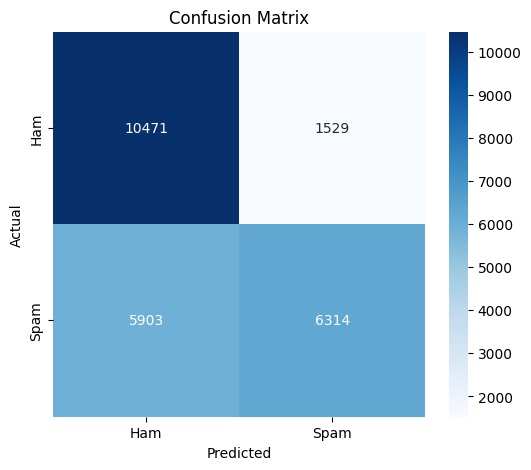

In [ ]:
# Visualize prediction errors: rows = actual labels, columns = predicted labels
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - K-Means Clustering (Combined)")
plt.tight_layout()
plt.show()


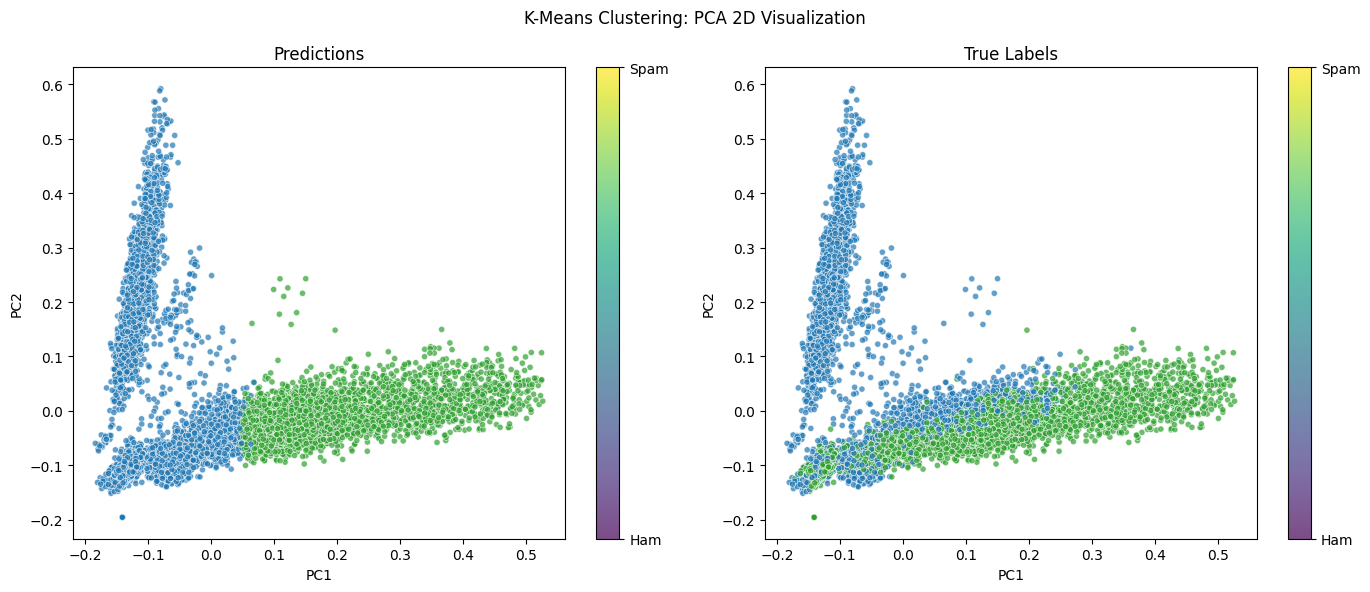

Explained variance ratio: [0.02686544 0.01779311]


In [10]:
# Side-by-side scatter plots compare predicted clusters vs true labels
# Reduce high-dimensional TF-IDF features to 2D with PCA for visualization
X_test_tfidf = pipeline.named_steps["tfidf"].transform(X_test)

sample_size = min(10000, X_test_tfidf.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test_tfidf.shape[0], sample_size, replace=False)

X_test_sample = X_test_tfidf[sample_idx, :]
y_test_sample = y_test.iloc[sample_idx]
y_pred_sample = y_pred[sample_idx]

pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(
    X_test_sample.toarray() if hasattr(X_test_sample, "toarray") else X_test_sample
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors_pred = np.where(y_pred_sample == 0, "#1f77b4", "#2ca02c")

sc1 = ax1.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=colors_pred,
    alpha=0.7,
    s=20,
    edgecolors="white",
    linewidths=0.5
)
ax1.set_title("Predictions")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_ticks([0, 1])
cbar1.set_ticklabels(["Ham", "Spam"])

colors_true = np.where(y_test_sample == 0, "#1f77b4", "#2ca02c")

sc2 = ax2.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=colors_true,
    alpha=0.7,
    s=20,
    edgecolors="white",
    linewidths=0.5
)
ax2.set_title("True Labels")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_ticks([0, 1])
cbar2.set_ticklabels(["Ham", "Spam"])

plt.suptitle("K-Means Clustering: PCA 2D Visualization")
plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")


In [11]:
# Top features per cluster reveal distinguishing words/patterns for each group
# Cluster centroids represent the average TF-IDF vector of all emails assigned to each cluster
tfidf = pipeline.named_steps["tfidf"]
feature_names = tfidf.get_feature_names_out().tolist()
cluster_centers = pipeline.named_steps["kmeans"].cluster_centers_

for cluster_id in [0, 1]:
    center = cluster_centers[cluster_id]
    top_indices = np.argsort(center)[-20:][::-1]
    mapped_label = map_0 if cluster_id == 0 else map_1
    print(f"\nTop 20 features for Cluster {cluster_id} (\u2192 label {mapped_label}):")
    for idx in top_indices:
        print(f"  {feature_names[idx]:30s} {center[idx]:+.4f}")



Top 20 features for Cluster 0 (→ label 0):
  url                            +0.0278
  ms                             +0.0200
  thread                         +0.0195
  microsoft                      +0.0151
  nahou                          +0.0148
  attach                         +0.0144
  use                            +0.0132
  return                         +0.0131
  class                          +0.0125
  mail                           +0.0125
  exchang                        +0.0123
  index                          +0.0123
  path                           +0.0122
  pleas                          +0.0121
  return path                    +0.0120
  microsoft exchang              +0.0120
  ms attach                      +0.0119
  exchang phonenumber            +0.0119
  thread index                   +0.0119
  binari                         +0.0119

Top 20 features for Cluster 1 (→ label 1):
  phonenumber receiv             +0.0633
  mailmanenroncom                +0.0571
  nahou   

In [12]:
# Run predefined test emails through the trained KMeans pipeline for qualitative evaluation
from src.test_emails import test_emails

test_clusters = pipeline.predict(test_emails)
test_mapped = np.where(test_clusters == 0, map_0, map_1)

test_tfidf = pipeline.named_steps["tfidf"].transform(test_emails)
test_dists = pipeline.named_steps["kmeans"].transform(test_tfidf)
spam_centroid = 0 if map_0 == 1 else 1
test_spam_probs = _sigmoid(-test_dists[:, spam_centroid])
test_probs = np.column_stack([1 - test_spam_probs, test_spam_probs])

print("=== Predictions ===")
for i, (email, pred, probs) in enumerate(zip(test_emails, test_mapped, test_probs)):
    label = "SPAM" if pred == 1 else "HAM"
    print(f"[{i}] {label} (ham: {probs[0]:.2%}, spam: {probs[1]:.2%}) \u2014 {email[:70]}...")


=== Predictions ===
[0] HAM (ham: 74.18%, spam: 25.82%) — Congratulations! You won $1000 free cash prize. Click here now to clai...
[1] HAM (ham: 74.21%, spam: 25.79%) — Hi John, please find attached the meeting notes from yesterday's call....
[2] HAM (ham: 74.17%, spam: 25.83%) — URGENT: Your account has been suspended. Verify now at http://scam-sit...
[3] HAM (ham: 74.22%, spam: 25.78%) — Can we reschedule tomorrow's lunch to 1pm instead?...
[4] HAM (ham: 74.17%, spam: 25.83%) — Buy cheap v1agra 100% free shipping limited offer act now!!!...
[5] HAM (ham: 74.15%, spam: 25.85%) — For your Assignment 1, word count of 3100 is already slightly too high...
[6] HAM (ham: 74.17%, spam: 25.83%) — Please be reminded that the Assignment 1 report is due this Sunday (17...
[7] HAM (ham: 74.16%, spam: 25.84%) — Show, Last weekend, I was sick and couldn't do much of anything. So I ...
[8] HAM (ham: 74.13%, spam: 25.87%) — Supporters can now pay you in USDC, and the money lands in your accoun...
[9

In [13]:
# Test a single email string and inspect distances to each cluster centroid for interpretability
email_text = "Congratulations! You won $1000 free cash prize. Click here now to claim!!!"

single_cluster = pipeline.predict([email_text])[0]
pred = map_0 if single_cluster == 0 else map_1

single_tfidf = pipeline.named_steps["tfidf"].transform([email_text])
dists = pipeline.named_steps["kmeans"].transform(single_tfidf)[0]
spam_centroid = 0 if map_0 == 1 else 1
single_spam_prob = _sigmoid(-dists[spam_centroid])
probs = np.array([1 - single_spam_prob, single_spam_prob])

label = "SPAM" if pred == 1 else "HAM"
print(f"Email: {email_text}")
print(f"Prediction: {label}")
print(f"Ham probability: {probs[0]:.2%}")
print(f"Spam probability: {probs[1]:.2%}")
print(f"Distance to centroid 0: {dists[0]:.4f}")
print(f"Distance to centroid 1: {dists[1]:.4f}")


Email: Congratulations! You won $1000 free cash prize. Click here now to claim!!!
Prediction: HAM
Ham probability: 74.18%
Spam probability: 25.82%
Distance to centroid 0: 1.0080
Distance to centroid 1: 1.0555


In [14]:
# Save the entire trained pipeline (preprocessor + classifier/clustering) for later deployment
joblib.dump(pipeline, MODEL_OUTPUT_DIR / "kmeans_combined_pipeline.pkl")
print(f"Saved K-Means pipeline to {MODEL_OUTPUT_DIR / 'kmeans_combined_pipeline.pkl'}")


Saved K-Means pipeline to C:\Users\aungm\university\computing\cos30049-email-spam-detection\models\kmeans_combined_pipeline.pkl
